# Build an NFL game prediction model with odds data

This notebook builds a simple Elo rating model from three seasons of NFL results, checks how well it predicts games it hasn't seen, then compares its picks with what sportsbooks are pricing for upcoming games.

Everything comes from [MoneyLine Sports API](https://www.moneylineapp.com). A run costs about 40 credits; the free plan includes 1,000 a month.

Set `MONEYLINE_API_KEY` in your environment before starting. [Get a free key](https://www.moneylineapp.com/signup).

In [1]:
# pip install moneyline-sports-api pandas matplotlib
from datetime import date
import math

import matplotlib.pyplot as plt
import pandas as pd
from moneyline_sports_api import MoneyLine

ml = MoneyLine()  # reads MONEYLINE_API_KEY

## 1. Load every final score since 2023

`/v1/events` returns 100 games per page (2 credits each). We keep finished games with real team names.

In [2]:
def final_games(league, since):
    rows, page = [], 1
    while True:
        res = ml.request("GET", "/v1/events", {"league": league, "status": "final", "from": since,
                                               "to": date.today().isoformat(), "limit": 100, "page": page})
        rows += res["data"]
        if page >= res["meta"]["pages"]:
            return rows
        page += 1

games = pd.DataFrame([
    {"start": g["startTime"], "home": g["homeTeamName"], "away": g["awayTeamName"],
     "home_score": g["scores"]["home"], "away_score": g["scores"]["away"]}
    for g in final_games("nfl", "2023-08-01")
    if g["homeTeamName"] != "TBD" and g["scores"]
])
games["start"] = pd.to_datetime(games["start"])
games = games.sort_values("start").reset_index(drop=True)
games["season"] = games["start"].apply(lambda t: t.year if t.month >= 8 else t.year - 1)
print(len(games), "games")
games.tail()

652 games


,start,home,away,home_score,away_score,season
647,2026-09-20 20:25:00+00:00,Arizona Cardinals,Seattle Seahawks,7,31,2026
648,2026-09-20 20:25:00+00:00,San Francisco 49ers,Miami Dolphins,35,13,2026
649,2026-09-20 20:25:00+00:00,Dallas Cowboys,Washington Commanders,37,20,2026
650,2026-09-21 00:20:00+00:00,Kansas City Chiefs,Indianapolis Colts,33,30,2026
651,2026-09-22 00:15:00+00:00,Los Angeles Rams,New York Giants,28,6,2026


## 2. Elo ratings

Every team starts at 1500. After each game the winner takes points from the loser, more for an upset. Home teams get a 48-point boost (about 2.5 points on the field), and ratings drift a third of the way back to 1500 between seasons.

In [3]:
K, HOME_EDGE, CARRYOVER = 20, 48, 2 / 3

def win_prob(home_elo, away_elo):
    return 1 / (1 + 10 ** ((away_elo - home_elo - HOME_EDGE) / 400))

ratings, season, preds = {}, None, []
for g in games.itertuples():
    if g.season != season:  # regress toward the mean each new season
        ratings = {t: 1500 + (r - 1500) * CARRYOVER for t, r in ratings.items()}
        season = g.season
    home, away = ratings.get(g.home, 1500), ratings.get(g.away, 1500)
    p = win_prob(home, away)
    home_won = 1.0 if g.home_score > g.away_score else 0.5 if g.home_score == g.away_score else 0.0
    preds.append({"season": g.season, "p_home": p, "home_won": home_won})
    margin_mult = math.log(abs(g.home_score - g.away_score) + 1)  # bigger wins move ratings more
    shift = K * margin_mult * (home_won - p)
    ratings[g.home], ratings[g.away] = home + shift, away - shift

preds = pd.DataFrame(preds)

## 3. How good is it?

We score only the most recent full season, after the model had two seasons to learn. The Brier score is the average squared error of the probabilities: 0.25 is a coin flip, and lower is better.

285 games  accuracy 64.6%  Brier 0.222  (coin flip: 0.250)


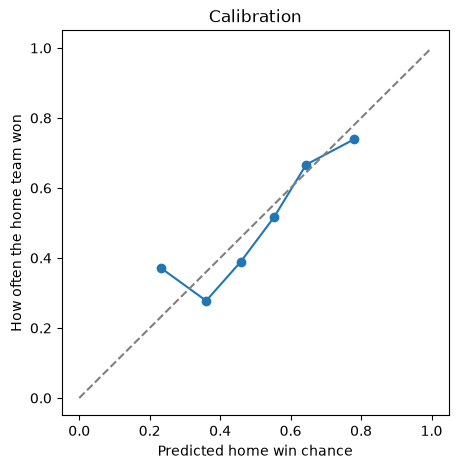

In [4]:
test = preds[preds.season == preds.season.max() - (1 if date.today().month >= 9 else 0)]
accuracy = ((test.p_home > 0.5) == (test.home_won == 1)).mean()
brier = ((test.p_home - test.home_won) ** 2).mean()
print(f"{len(test)} games  accuracy {accuracy:.1%}  Brier {brier:.3f}  (coin flip: 0.250)")

bins = pd.cut(test.p_home, [0, .3, .4, .5, .6, .7, 1])
calib = test.groupby(bins, observed=True).agg(predicted=("p_home", "mean"), actual=("home_won", "mean"))
ax = calib.plot(x="predicted", y="actual", marker="o", legend=False, figsize=(5, 5))
ax.plot([0, 1], [0, 1], linestyle="--", color="gray")
ax.set(xlabel="Predicted home win chance", ylabel="How often the home team won", title="Calibration")
plt.show()

## 4. Compare with the betting market

Now price this week's games. `/v1/odds` returns every sportsbook's moneyline (18 credits). We remove each book's margin (the vig) to get a fair market probability, then take the median across sportsbooks.

In [5]:
def market_home_prob(game):
    fair = []
    for book in game["bookmakers"]:
        if book["sourceType"] != "sportsbook":
            continue
        prices = {o["name"]: o["impliedProbability"] for m in book["markets"] for o in m["outcomes"]}
        home, away = prices.get(game["homeTeamName"]), prices.get(game["awayTeamName"])
        if home and away:
            fair.append(home / (home + away))  # remove the vig
    return pd.Series(fair).median() if fair else None

rows = []
for g in ml.odds(league="nfl", market="moneyline"):
    market = market_home_prob(g)
    if market is None:
        continue
    model = win_prob(ratings.get(g["homeTeamName"], 1500), ratings.get(g["awayTeamName"], 1500))
    rows.append({"game": f"{g['awayTeamName']} at {g['homeTeamName']}", "start": g["startTime"][:10],
                 "model_home": round(model, 3), "market_home": round(market, 3),
                 "gap": round(model - market, 3)})

board = pd.DataFrame(rows).sort_values("gap", key=abs, ascending=False)
board.head(10)

,game,start,model_home,market_home,gap
23,Indianapolis Colts at Washington Commanders,2026-10-04,0.620,0.341,0.280
11,Philadelphia Eagles at Chicago Bears,2026-09-29,0.605,0.331,0.274
2,Tennessee Titans at New York Giants,2026-09-27,0.743,0.570,0.173
4,Kansas City Chiefs at Miami Dolphins,2026-09-27,0.325,0.160,0.165
24,New York Jets at Chicago Bears,2026-10-04,0.771,0.617,0.154
10,Los Angeles Chargers at Buffalo Bills,2026-09-27,0.827,0.744,0.083
12,Los Angeles Rams at Denver Broncos,2026-09-28,0.517,0.441,0.075
5,New York Jets at Detroit Lions,2026-09-27,0.789,0.719,0.070
15,Minnesota Vikings at Tampa Bay Buccaneers,2026-09-27,0.400,0.468,-0.068
0,Arizona Cardinals at San Francisco 49ers,2026-09-27,0.831,0.776,0.056


## What to take from it

- A plain Elo model gets close to the market on most games, which shows how much information is already in the line.
- The biggest gaps are where the market knows something Elo can't: injuries, quarterback changes, weather. Treat them as questions to research, not bets.
- To improve it, add features the API already returns, such as injuries (`/v1/teams/{teamId}/injuries`) and player hit rates, and backtest against the line history in `/v1/events/{eventId}/odds-history`.

The code is on [GitHub](https://github.com/moneyline-sports-api/examples/tree/main/game-prediction-notebook).